
In this tutorial, we build **MoodTrack**, a full-stack mental health analytics dashboard using synthetic PHQ-9-like longitudinal data.

The system includes:

- Python synthetic data generation
- Node.js + Express backend API
- SQLite database
- React frontend dashboard
- Prediction API
- Deployment using Render and Netlify


```text

This project is on a synthetic dataset. 

```



## 1. Final Architecture

```text
Synthetic PHQ-9 Data Generation
        ↓
SQLite Database
        ↓
Express Backend API
        ↓
Prediction Logic
        ↓
React Frontend Dashboard
        ↓
Deployment using Render + Netlify
```


### Final project structure:

```text
blog_mood_track/
├── backend/
│   ├── server.js
│   ├── package.json
│   ├── .env
│   ├── data/
│   │   ├── moodtrack_synthetic_phq9_dataset.csv
│   │   └── moodtrack_user_summary.csv
│   ├── db/
│   │   ├── database.js
│   │   ├── initDatabase.js
│   │   └── moodtrack.db
│   └── routes/
│       ├── users.js
│       ├── mood.js
│       ├── summary.js
│       └── prediction.js
├── frontend/
│   ├── .env
│   ├── package.json
│   └── src/
│       ├── App.js
│       ├── App.css
│       └── components/
│           ├── UserSelector.js
│           ├── MoodChart.js
│           ├── SummaryCards.js
│           └── PredictionCard.js
└── notebooks/
    └── moodtrack_fullstack_tutorial.ipynb
```

## 2. Synthetic PHQ-9 Data Generation

Real PHQ-9 data is sensitive and cannot be used publicly. Therefore, we generate synthetic longitudinal PHQ-9-like data.

The simulated dataset includes:

- 300 synthetic users
- 12 weekly observations per user
- PHQ-9 scores from 0 to 27
- trajectory patterns: stable, improving, worsening, relapse, fluctuating
- extra variables: sleep, stress, activity, medication status


In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_users = 300
n_weeks = 12

trajectory_types = [
    "stable_low",
    "stable_moderate",
    "improving",
    "worsening",
    "relapse",
    "fluctuating"
]

trajectory_probs = [0.20, 0.20, 0.20, 0.15, 0.10, 0.15]

def phq9_category(score):
    if score <= 4:
        return "minimal"
    elif score <= 9:
        return "mild"
    elif score <= 14:
        return "moderate"
    elif score <= 19:
        return "moderately_severe"
    else:
        return "severe"

records = []

for user_id in range(1, n_users + 1):
    age = int(np.clip(np.random.normal(38, 12), 18, 75))
    sex = np.random.choice(["female", "male"], p=[0.58, 0.42])
    trajectory = np.random.choice(trajectory_types, p=trajectory_probs)

    baseline = {
        "stable_low": np.random.normal(4, 2),
        "stable_moderate": np.random.normal(12, 3),
        "improving": np.random.normal(17, 4),
        "worsening": np.random.normal(6, 3),
        "relapse": np.random.normal(9, 3),
        "fluctuating": np.random.normal(11, 4),
    }[trajectory]

    for week in range(1, n_weeks + 1):
        noise = np.random.normal(0, 1.8)

        if trajectory == "stable_low":
            score = baseline + noise
        elif trajectory == "stable_moderate":
            score = baseline + noise
        elif trajectory == "improving":
            score = baseline - (week - 1) * np.random.uniform(0.7, 1.2) + noise
        elif trajectory == "worsening":
            score = baseline + (week - 1) * np.random.uniform(0.6, 1.1) + noise
        elif trajectory == "relapse":
            if week <= 6:
                score = baseline - week * np.random.uniform(0.4, 0.9) + noise
            else:
                score = baseline - 4 + (week - 6) * np.random.uniform(1.0, 1.7) + noise
        else:
            score = baseline + 4 * np.sin(week / 1.5) + noise

        score = int(np.clip(round(score), 0, 27))

        records.append({
            "user_id": f"U{user_id:04d}",
            "week": week,
            "age": age,
            "sex": sex,
            "trajectory_type": trajectory,
            "phq9_score": score,
            "phq9_category": phq9_category(score),
            "sleep_hours": round(np.clip(np.random.normal(7 - score * 0.08, 1.0), 3, 10), 1),
            "physical_activity_days": int(np.clip(round(np.random.normal(4 - score * 0.12, 1.5)), 0, 7)),
            "stress_level": int(np.clip(round(np.random.normal(3 + score * 0.22, 1.3)), 1, 10)),
            "medication_status": np.random.choice(["none", "started", "ongoing"], p=[0.55, 0.15, 0.30])
        })

df = pd.DataFrame(records)
df["high_risk_flag"] = df["phq9_score"] >= 15
df["created_at"] = pd.Timestamp("2026-01-01") + pd.to_timedelta((df["week"] - 1) * 7, unit="D")

df.head()

,user_id,week,age,sex,trajectory_type,phq9_score,phq9_category,sleep_hours,physical_activity_days,stress_level,medication_status,high_risk_flag,created_at
0,U0001,1,43,male,improving,17,moderately_severe,5.1,1,3,none,True,2026-01-01
1,U0001,2,43,male,improving,17,moderately_severe,5.2,1,6,ongoing,True,2026-01-08
2,U0001,3,43,male,improving,11,moderate,8.7,3,6,none,False,2026-01-15
3,U0001,4,43,male,improving,13,moderate,5.4,4,6,none,False,2026-01-22
4,U0001,5,43,male,improving,12,moderate,5.5,3,5,started,False,2026-01-29


In [2]:
summary = (
    df.groupby("user_id")
    .agg(
        age=("age", "first"),
        sex=("sex", "first"),
        trajectory_type=("trajectory_type", "first"),
        baseline_score=("phq9_score", "first"),
        final_score=("phq9_score", "last"),
        mean_score=("phq9_score", "mean"),
        max_score=("phq9_score", "max"),
        min_score=("phq9_score", "min"),
        high_risk_weeks=("high_risk_flag", "sum")
    )
    .reset_index()
)

summary["change_from_baseline"] = summary["final_score"] - summary["baseline_score"]

df.to_csv("moodtrack_synthetic_phq9_dataset.csv", index=False)
summary.to_csv("moodtrack_user_summary.csv", index=False)

print(df.shape)
print(summary.shape)

summary.head()

(3600, 13)
(300, 11)


,user_id,age,sex,trajectory_type,baseline_score,final_score,mean_score,max_score,min_score,high_risk_weeks,change_from_baseline
0,U0001,43,male,improving,17,6,11.500000,17,6,2,-11
1,U0002,50,male,stable_moderate,9,11,10.750000,14,9,0,2
2,U0003,28,male,fluctuating,7,9,5.666667,10,0,0,2
3,U0004,38,male,worsening,9,16,10.833333,16,7,2,7
4,U0005,36,male,fluctuating,13,12,9.916667,14,5,0,-1


After generating the data, copy both CSV files into the backend data folder:

```bash
mkdir -p backend/data
cp moodtrack_synthetic_phq9_dataset.csv backend/data/
cp moodtrack_user_summary.csv backend/data/
```

## 3. Exploratory Data Analysis

Before building the application, we inspect the generated data to understand the PHQ-9 score distribution and example trajectories.

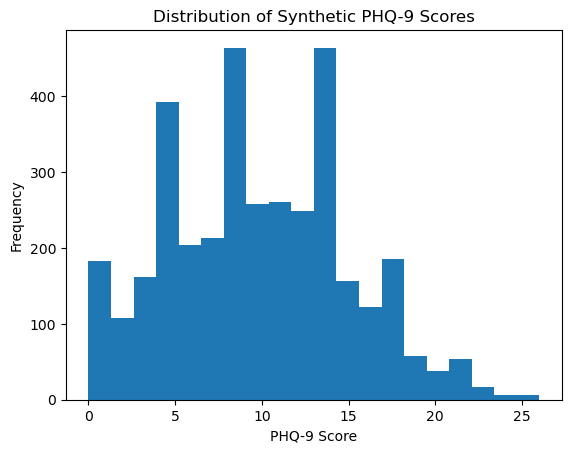

In [3]:
import matplotlib.pyplot as plt

plt.hist(df["phq9_score"], bins=20)
plt.xlabel("PHQ-9 Score")
plt.ylabel("Frequency")
plt.title("Distribution of Synthetic PHQ-9 Scores")
plt.show()

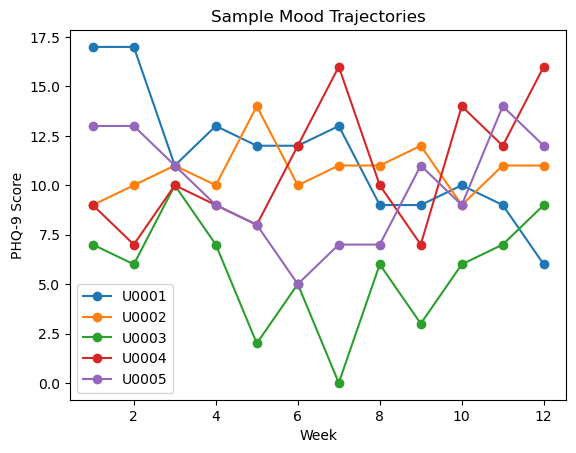

In [4]:
sample_users = df["user_id"].unique()[:5]

for user in sample_users:
    temp = df[df["user_id"] == user]
    plt.plot(temp["week"], temp["phq9_score"], marker="o", label=user)

plt.xlabel("Week")
plt.ylabel("PHQ-9 Score")
plt.title("Sample Mood Trajectories")
plt.legend()
plt.show()

## 4. Backend Setup

The backend is built using **Node.js** and **Express**.

Create the backend folder and initialize the project.

```bash
mkdir backend
cd backend

npm init -y

npm install express cors csv-parser dotenv sqlite sqlite3
npm install --save-dev nodemon
```

Create folders and files:

```bash
mkdir data
mkdir routes
mkdir db

touch server.js
touch .env

touch routes/users.js
touch routes/mood.js
touch routes/summary.js
touch routes/prediction.js

touch db/database.js
touch db/initDatabase.js

```

Add this to `backend/.env`

PORT=5000

## 5. Backend `package.json`

Replace the automatically generated `backend/package.json` with the following:

```bash
{
  "name": "moodtrack-backend",
  "version": "1.0.0",
  "main": "server.js",
  "scripts": {
    "start": "node server.js",
    "dev": "nodemon server.js"
  },
  "dependencies": {
    "cors": "^2.8.5",
    "csv-parser": "^3.2.0",
    "dotenv": "^16.4.7",
    "express": "^5.1.0",
    "sqlite": "^5.1.1",
    "sqlite3": "^5.1.7"
  },
  "devDependencies": {
    "nodemon": "^3.1.10"
  }
}
```

## 6. SQLite Database Connection

We now create the SQLite connection layer.

```bash

const sqlite3 = require("sqlite3");
const { open } = require("sqlite");
const path = require("path");

async function openDatabase() {
  return open({
    filename: path.join(__dirname, "moodtrack.db"),
    driver: sqlite3.Database
  });
}

module.exports = openDatabase;

```

## 7. Initialize SQLite Database

This script:

- creates tables
- reads CSV files
- inserts data into SQLite

### `backend/db/initDatabase.js`

```bahs
const fs = require("fs");
const csv = require("csv-parser");
const path = require("path");
const openDatabase = require("./database");

function loadCSV(filePath) {
  return new Promise((resolve, reject) => {
    const results = [];

    fs.createReadStream(filePath)
      .pipe(csv())
      .on("data", (row) => results.push(row))
      .on("end", () => resolve(results))
      .on("error", (err) => reject(err));
  });
}

async function initDatabase() {
  const db = await openDatabase();

  await db.exec(`
    DROP TABLE IF EXISTS mood_records;
    DROP TABLE IF EXISTS user_summary;

    CREATE TABLE mood_records (
      id INTEGER PRIMARY KEY AUTOINCREMENT,
      user_id TEXT,
      week INTEGER,
      age INTEGER,
      sex TEXT,
      trajectory_type TEXT,
      phq9_score INTEGER,
      phq9_category TEXT,
      sleep_hours REAL,
      physical_activity_days INTEGER,
      stress_level INTEGER,
      medication_status TEXT,
      high_risk_flag TEXT,
      created_at TEXT
    );

    CREATE TABLE user_summary (
      user_id TEXT PRIMARY KEY,
      age INTEGER,
      sex TEXT,
      trajectory_type TEXT,
      baseline_score INTEGER,
      final_score INTEGER,
      mean_score REAL,
      max_score INTEGER,
      min_score INTEGER,
      high_risk_weeks INTEGER,
      change_from_baseline INTEGER
    );
  `);

  const moodData = await loadCSV(
    path.join(__dirname, "..", "data", "moodtrack_synthetic_phq9_dataset.csv")
  );

  const summaryData = await loadCSV(
    path.join(__dirname, "..", "data", "moodtrack_user_summary.csv")
  );

  for (const row of moodData) {
    await db.run(
      `
      INSERT INTO mood_records (
        user_id, week, age, sex, trajectory_type, phq9_score,
        phq9_category, sleep_hours, physical_activity_days,
        stress_level, medication_status, high_risk_flag, created_at
      )
      VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
      `,
      [
        row.user_id,
        Number(row.week),
        Number(row.age),
        row.sex,
        row.trajectory_type,
        Number(row.phq9_score),
        row.phq9_category,
        Number(row.sleep_hours),
        Number(row.physical_activity_days),
        Number(row.stress_level),
        row.medication_status,
        row.high_risk_flag,
        row.created_at
      ]
    );
  }

  for (const row of summaryData) {
    await db.run(
      `
      INSERT INTO user_summary (
        user_id, age, sex, trajectory_type, baseline_score,
        final_score, mean_score, max_score, min_score,
        high_risk_weeks, change_from_baseline
      )
      VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
      `,
      [
        row.user_id,
        Number(row.age),
        row.sex,
        row.trajectory_type,
        Number(row.baseline_score),
        Number(row.final_score),
        Number(row.mean_score),
        Number(row.max_score),
        Number(row.min_score),
        Number(row.high_risk_weeks),
        Number(row.change_from_baseline)
      ]
    );
  }

  console.log("SQLite database initialized successfully.");
  console.log("Mood records inserted:", moodData.length);
  console.log("Summary records inserted:", summaryData.length);

  await db.close();
}

initDatabase();

```

Run the initialization script:

```bash
cd backend
node db/initDatabase.js
```

Expected output:

```bash
SQLite database initialized successfully.
Mood records inserted: 3600
Summary records inserted: 300
```

## 8. Backend Route Files

The backend exposes multiple REST API endpoints.

### `backend/routes/users.js`

```bash
const express = require("express");
const router = express.Router();

module.exports = function (db) {
  router.get("/", async (req, res) => {
    try {
      const users = await db.all(
        "SELECT DISTINCT user_id FROM mood_records ORDER BY user_id"
      );

      res.json(users.map((row) => row.user_id));
    } catch (error) {
      res.status(500).json({ error: error.message });
    }
  });

  return router;
};
```

### `backend/routes/mood.js`

```bash
const express = require("express");
const router = express.Router();

module.exports = function (db) {

  router.get("/", async (req, res) => {
    try {
      const rows = await db.all("SELECT * FROM mood_records");
      res.json(rows);
    } catch (error) {
      res.status(500).json({ error: error.message });
    }
  });

  router.get("/:user_id", async (req, res) => {
    try {
      const rows = await db.all(
        "SELECT * FROM mood_records WHERE user_id = ? ORDER BY week",
        [req.params.user_id]
      );

      if (rows.length === 0) {
        return res.status(404).json({ error: "User not found" });
      }

      res.json(rows);

    } catch (error) {
      res.status(500).json({ error: error.message });
    }
  });

  return router;
};
```

### `backend/routes/summary.js`


```bash
const express = require("express");
const router = express.Router();

module.exports = function (db) {

  router.get("/", async (req, res) => {
    try {
      const rows = await db.all(
        "SELECT * FROM user_summary ORDER BY user_id"
      );

      res.json(rows);

    } catch (error) {
      res.status(500).json({ error: error.message });
    }
  });

  return router;
};
```

### Part 3: Prediction API + Backend Server + Local Backend Test

## 9. Prediction API

To add a simple machine learning-style component, we create a prediction endpoint.

The model uses a simple linear trend over the user's PHQ-9 trajectory to estimate the next week's PHQ-9 score.

This is not intended as a clinical model. It is used to demonstrate how predictive logic can be exposed through an API.

### `backend/routes/prediction.js`

```bash
const express = require("express");
const router = express.Router();

function linearRegression(data) {
  const n = data.length;

  const sumX = data.reduce((sum, row) => sum + row.week, 0);
  const sumY = data.reduce((sum, row) => sum + row.phq9_score, 0);
  const sumXY = data.reduce((sum, row) => sum + row.week * row.phq9_score, 0);
  const sumX2 = data.reduce((sum, row) => sum + row.week * row.week, 0);

  const slope =
    (n * sumXY - sumX * sumY) /
    (n * sumX2 - sumX * sumX);

  const intercept = (sumY - slope * sumX) / n;

  return { slope, intercept };
}

module.exports = function (db) {
  router.get("/:user_id", async (req, res) => {
    try {
      const rows = await db.all(
        "SELECT week, phq9_score FROM mood_records WHERE user_id = ? ORDER BY week",
        [req.params.user_id]
      );

      if (rows.length === 0) {
        return res.status(404).json({ error: "User not found" });
      }

      const data = rows.map((row) => ({
        week: Number(row.week),
        phq9_score: Number(row.phq9_score)
      }));

      const { slope, intercept } = linearRegression(data);

      const nextWeek = Math.max(...data.map((row) => row.week)) + 1;
      let predictedScore = slope * nextWeek + intercept;

      predictedScore = Math.round(Math.max(0, Math.min(27, predictedScore)));

      let riskLevel = "low";

      if (predictedScore >= 15) {
        riskLevel = "high";
      } else if (predictedScore >= 10) {
        riskLevel = "moderate";
      }

      res.json({
        user_id: req.params.user_id,
        next_week: nextWeek,
        predicted_phq9_score: predictedScore,
        trend_slope: Number(slope.toFixed(2)),
        risk_level: riskLevel
      });

    } catch (error) {
      res.status(500).json({ error: error.message });
    }
  });

  return router;
};
```

## 10. Backend Server

Now we connect the database and all route files in the main backend server.

### `backend/server.js`

```bash
const express = require("express");
const cors = require("cors");
require("dotenv").config();

const openDatabase = require("./db/database");

const usersRouter = require("./routes/users");
const moodRouter = require("./routes/mood");
const summaryRouter = require("./routes/summary");
const predictionRouter = require("./routes/prediction");

const app = express();
const PORT = process.env.PORT || 5000;

app.use(cors());
app.use(express.json());

async function startServer() {
  try {
    const db = await openDatabase();

    app.get("/", (req, res) => {
      res.json({
        status: "OK",
        message: "MoodTrack backend is live"
      });
    });

    app.get("/api/health", (req, res) => {
      res.json({
        status: "OK",
        message: "MoodTrack API is running with SQLite"
      });
    });

    app.use("/api/users", usersRouter(db));
    app.use("/api/mood", moodRouter(db));
    app.use("/api/summary", summaryRouter(db));
    app.use("/api/prediction", predictionRouter(db));

    app.listen(PORT, () => {
      console.log("MoodTrack API running on port " + PORT);
      console.log("Connected to SQLite database");
    });

  } catch (error) {
    console.error("Failed to start server:", error);
  }
}

startServer();
```

## 11. Running the Backend Locally

Start the backend server:

```bash
cd backend
npm run dev
```

Expected terminal output:

MoodTrack API running on port 5000

Connected to SQLite database

Test the following API endpoints in the browser:

http://localhost:5000/

http://localhost:5000/api/health

http://localhost:5000/api/users

http://localhost:5000/api/mood/U0001

http://localhost:5000/api/summary

http://localhost:5000/api/prediction/U0001

Example prediction output:

```bash
{
  "user_id": "U0001",
  "next_week": 13,
  "predicted_phq9_score": 8,
  "trend_slope": -0.35,
  "risk_level": "low"
}
```

At this stage, we have a working backend API connected to a SQLite database.

## 12. React Frontend Setup

Next, we create the React frontend.

The frontend will:

- fetch users from the backend
- allow user selection
- show PHQ-9 trajectory
- display summary statistics
- show prediction output

```bash
npx create-react-app frontend
cd frontend

npm install axios recharts
```

Create the frontend environment file:

```bash
vim .env
```

Add this to `frontend/.env`:

REACT_APP_API_URL=http://localhost:5000

Create component files:

```bash
cd src

mkdir components

vim components/UserSelector.js

vim components/MoodChart.js

vim components/SummaryCards.js

vim components/PredictionCard.js
```

## 13. Frontend Components

### `frontend/src/components/UserSelector.js`

```bash
function UserSelector({ users, selectedUser, onUserChange }) {
  return (
    <div className="card">
      <h2>Select User</h2>

      <select
        value={selectedUser}
        onChange={(e) => onUserChange(e.target.value)}
      >
        {users.map((user) => (
          <option key={user} value={user}>
            {user}
          </option>
        ))}
      </select>
    </div>
  );
}

export default UserSelector;
```

### `frontend/src/components/MoodChart.js`

```bash
import {
  LineChart,
  Line,
  XAxis,
  YAxis,
  CartesianGrid,
  Tooltip,
  ResponsiveContainer
} from "recharts";

function MoodChart({ moodData }) {
  return (
    <div className="card">
      <h2>PHQ-9 Score Over Time</h2>

      <ResponsiveContainer width="100%" height={350}>
        <LineChart data={moodData}>
          <CartesianGrid strokeDasharray="3 3" />
          <XAxis dataKey="week" />
          <YAxis domain={[0, 27]} />
          <Tooltip />
          <Line
            type="monotone"
            dataKey="phq9_score"
            strokeWidth={3}
          />
        </LineChart>
      </ResponsiveContainer>
    </div>
  );
}

export default MoodChart;
```

### `frontend/src/components/SummaryCards.js`

```bash
function SummaryCards({ selectedUser, summaryData }) {
  const userSummary = summaryData.find(
    (row) => row.user_id === selectedUser
  );

  if (!userSummary) {
    return null;
  }

  return (
    <div className="summary-grid">
      <div className="summary-card">
        <h3>Baseline Score</h3>
        <p>{userSummary.baseline_score}</p>
      </div>

      <div className="summary-card">
        <h3>Final Score</h3>
        <p>{userSummary.final_score}</p>
      </div>

      <div className="summary-card">
        <h3>Mean Score</h3>
        <p>{Number(userSummary.mean_score).toFixed(1)}</p>
      </div>

      <div className="summary-card">
        <h3>High-Risk Weeks</h3>
        <p>{userSummary.high_risk_weeks}</p>
      </div>
    </div>
  );
}

export default SummaryCards;

```

### `frontend/src/components/PredictionCard.js`

```bash
function PredictionCard({ prediction }) {
  if (!prediction) {
    return null;
  }

  return (
    <div className="prediction-card">
      <h2>Next Week Prediction</h2>

      <p>
        Predicted PHQ-9 score for week {prediction.next_week}:
        <strong> {prediction.predicted_phq9_score}</strong>
      </p>

      <p>
        Trend slope:
        <strong> {prediction.trend_slope}</strong>
      </p>

      <p>
        Risk level:
        <strong> {prediction.risk_level}</strong>
      </p>
    </div>
  );
}

export default PredictionCard;
```

## 14. Frontend `App.js`

The main React app connects all components together.

It fetches:

- user IDs from `/api/users`
- summary data from `/api/summary`
- selected user trajectory from `/api/mood/:user_id`
- prediction output from `/api/prediction/:user_id`

### `frontend/src/App.js`

```bash
import React, { useEffect, useState } from "react";
import axios from "axios";
import "./App.css";

import UserSelector from "./components/UserSelector";
import MoodChart from "./components/MoodChart";
import SummaryCards from "./components/SummaryCards";
import PredictionCard from "./components/PredictionCard";

const API_URL = process.env.REACT_APP_API_URL;

function App() {
  const [users, setUsers] = useState([]);
  const [selectedUser, setSelectedUser] = useState("");
  const [moodData, setMoodData] = useState([]);
  const [summaryData, setSummaryData] = useState([]);
  const [prediction, setPrediction] = useState(null);

  useEffect(() => {
    axios
      .get(API_URL + "/api/users")
      .then((res) => {
        setUsers(res.data);
        setSelectedUser(res.data[0]);
      })
      .catch((err) => console.error("Error fetching users:", err));

    axios
      .get(API_URL + "/api/summary")
      .then((res) => {
        setSummaryData(res.data);
      })
      .catch((err) => console.error("Error fetching summary:", err));
  }, []);

  useEffect(() => {
    if (selectedUser) {
      axios
        .get(API_URL + "/api/mood/" + selectedUser)
        .then((res) => {
          const cleanedData = res.data.map((row) => ({
            week: Number(row.week),
            phq9_score: Number(row.phq9_score)
          }));

          setMoodData(cleanedData);
        })
        .catch((err) => console.error("Error fetching mood data:", err));

      axios
        .get(API_URL + "/api/prediction/" + selectedUser)
        .then((res) => {
          setPrediction(res.data);
        })
        .catch((err) => console.error("Error fetching prediction:", err));
    }
  }, [selectedUser]);

  return (
    <div className="App">
      <header className="header">
        <h1>MoodTrack Dashboard</h1>
        <p>Visualizing synthetic PHQ-9 trajectories with predictive insights</p>
      </header>

      <main className="container">
        <UserSelector
          users={users}
          selectedUser={selectedUser}
          onUserChange={setSelectedUser}
        />

        <SummaryCards
          selectedUser={selectedUser}
          summaryData={summaryData}
        />

        <PredictionCard prediction={prediction} />

        <MoodChart moodData={moodData} />
      </main>
    </div>
  );
}

export default App;
```

## 15. Frontend Styling

The CSS file gives the dashboard a clean card-based layout.

### `frontend/src/App.css`

```bash
.App {
  font-family: Arial, sans-serif;
  background: #f5f7fb;
  min-height: 100vh;
}

.header {
  background: #253858;
  color: white;
  padding: 30px;
  text-align: center;
}

.header h1 {
  margin: 0;
  font-size: 36px;
}

.header p {
  margin-top: 10px;
  font-size: 16px;
}

.container {
  max-width: 1000px;
  margin: 30px auto;
  padding: 20px;
}

.card {
  background: white;
  padding: 25px;
  margin-bottom: 25px;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.08);
}

.card h2 {
  margin-top: 0;
}

select {
  padding: 10px;
  font-size: 16px;
  width: 200px;
}

.summary-grid {
  display: grid;
  grid-template-columns: repeat(4, 1fr);
  gap: 20px;
  margin-bottom: 25px;
}

.summary-card {
  background: white;
  padding: 20px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 4px 12px rgba(0,0,0,0.08);
}

.summary-card h3 {
  margin: 0;
  font-size: 16px;
}

.summary-card p {
  font-size: 28px;
  font-weight: bold;
  margin: 10px 0 0;
}

.prediction-card {
  background: white;
  padding: 25px;
  margin-bottom: 25px;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.08);
}

.prediction-card h2 {
  margin-top: 0;
}

.prediction-card strong {
  font-size: 20px;
}
```

## 16. Running the Full Application Locally

The application has two parts:

1. Backend API
2. React frontend

Both must run at the same time.

### Terminal 1 — Start Backend

```bash
cd backend
npm run dev
```

Expected backend output:

```bash
MoodTrack API running on port 5000
Connected to SQLite database
```

### Terminal 2 — Start Frontend

```bash
cd frontend
unset HOST
npm start
```

Open the frontend in your browser:

```bash
http://localhost:3000
```

If React says port 3000 is already in use, press `Y` to use another port.

At this point, the dashboard should show:

- user dropdown
- PHQ-9 trajectory plot
- summary cards
- prediction card

## 17. Deployment

After confirming that the application works locally, we deploy it using free hosting platforms.

The deployment architecture is:

```text
React Frontend  →  Netlify
Express Backend →  Render
SQLite Database →  included in backend deployment

```

This gives us a publicly accessible full-stack data science application.


## 18. Deploy Backend on Render

The backend is deployed as a Render Web Service.

Before deployment, make sure the backend has:

- `server.js`
- `package.json`
- `routes/`
- `db/moodtrack.db`
- `db/database.js`
- `db/initDatabase.js`

Render settings:

```text
Root Directory: backend
Build Command: npm install
Start Command: npm start
Instance Type: Free

```

After deployment, Render provides a backend URL such as:

```text
https://moodtrack-backend.onrender.com
```

Test the deployed backend:

```text
https://moodtrack-backend.onrender.com/
https://moodtrack-backend.onrender.com/api/health
```

Expected output:

```text

{
  "status": "OK",
  "message": "MoodTrack API is running with SQLite"
}

```


## 19. Deploy Frontend on Netlify

The React frontend is deployed using Netlify.

Netlify settings:

```text
Base directory: frontend
Build command: npm run build
Publish directory: build
```

Add this environment variable in Netlify:

```text
REACT_APP_API_URL=https://moodtrack-backend.onrender.com
```

This tells the deployed frontend to call the deployed backend API instead of the local backend.

After deployment, Netlify provides a live frontend URL such as:

```text

https://your-site-name.netlify.app

```



## 20. Final Application Output

The deployed MoodTrack dashboard includes:

- A user selector
- PHQ-9 trajectory visualization
- Baseline score
- Final score
- Mean score
- High-risk week count
- Next-week PHQ-9 prediction
- Risk classification

Live links:

```text
Frontend: YOUR_NETLIFY_LINK
Backend: https://moodtrack-backend.onrender.com

```

Replace YOUR_NETLIFY_LINK with your actual deployed Netlify link.

![MoodTrack Dashboard](frontend_image.png)



## 22. What We Built

In this project, we built a complete full-stack analytics system:

```text
Synthetic PHQ-9 Data
        ↓
SQLite Database
        ↓
Express REST API
        ↓
Prediction Endpoint
        ↓
React Dashboard
        ↓
Cloud Deployment
```

This demonstrates how a data science workflow can be transformed into a deployable application.



## 23. Key Learning Outcomes

This project covers:

- synthetic data generation
- longitudinal PHQ-9 trajectory simulation
- exploratory visualization
- backend API development
- REST API design
- SQLite database integration
- modular backend route structure
- React frontend component design
- charting with Recharts
- environment variable configuration
- simple predictive modeling
- deployment using Render and Netlify

## 24. Limitations

This project has important limitations:

- The dataset is synthetic and does not represent real patients.
- The prediction model is a simple linear trend model.
- The system is not clinically validated.
- There is no authentication or user-level privacy layer.
- SQLite is suitable for demonstration, but not ideal for production-scale deployment.
- Render free services may sleep after inactivity, so the first request may be slow.

This project should be understood as an educational full-stack data science demonstration, not a medical device or clinical decision-support tool.

## 25. Future Work

Future improvements could include:

- replacing SQLite with PostgreSQL or Azure SQL
- adding user authentication
- adding role-based access control
- improving the ML model
- adding relapse detection
- adding anomaly detection
- creating population-level analytics
- deploying a production version on Azure
- adding logging and monitoring
- adding automated tests

## 26. Azure Extension

The current free deployment uses:

```text
Frontend: Netlify
Backend: Render
Database: SQLite
```

A production Azure version could use:
```text

Frontend: Azure Static Web Apps
Backend: Azure App Service
Database: Azure SQL Database
```


The conceptual architecture remains the same:

```text
React Frontend → Backend API → Database
```

The main difference is that Azure SQL would replace the local SQLite file with a managed cloud database.


## 27. Conclusion

In this tutorial, we built and deployed MoodTrack, a full-stack mental health analytics dashboard using synthetic PHQ-9 data.

The project demonstrates how data science, backend engineering, frontend visualization, predictive modeling, and deployment can be combined into a single end-to-end application.

This project is useful as a portfolio project because it shows not only analysis, but also the ability to turn analytical work into an interactive, deployable product.